## Set up data and model objects


In [1]:
import pandas as pd
import numpy as np
import mudata as md
from perturbo import run_svi, run_mcmc, perturbseq_guide_autonormal_turbo, perturbseq_model_turbo
import seaborn as sns
import matplotlib.pyplot as plt
import jax.numpy as jnp


test_ntcs = False

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


Set training configuration and access to data


### Load the data

(50k cells, takes ~30 seconds)


In [2]:
data_dir = "../../../../Data/gasperini_pilot"

mdata = md.read_h5mu(f"{data_dir}/gasperini_pilot_highMOI.h5mu")
# batch_size=None
mdata

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


MuData object with n_obs × n_vars = 47964 × 19482
  2 modalities
    rna:	47964 x 16367
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 3115
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [3]:
mdata["grna"]

AnnData object with n_obs × n_vars = 47964 × 3115
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
    varm: 'element_targeted'

In [33]:
# element = "ACTB_TSS"
# element = "ACTG1_TSS"
element_guides = [x for x in mdata["grna"].var_names if "_TSS" in x]
# element_guides = mdata["grna"].varm["element_targeted"][element]
len(element_guides)

762

In [5]:
control_guides = [x for x in mdata["grna"].var_names if "random" in x or "scrambled" in x]
len(control_guides)
# control_guides = pd.Series(np.zeros(len(element_guides)), index=element_guides)
# control_guides[-50:] = 1
# control_guides

100

In [6]:
selected_guides = element_guides + control_guides
selected_cells = mdata["grna"][:, selected_guides].X.sum(axis=1) > 0
selected_cells.sum()

45053

In [7]:
if test_ntcs:
    grna_subset = mdata["grna"][:, selected_guides]
else:
    grna_subset = mdata["grna"][:, element_guides]
grna_subset = grna_subset[selected_cells, :]
grna_subset

View of AnnData object with n_obs × n_vars = 45053 × 762
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
    varm: 'element_targeted'

In [8]:
mdata["rna"].var_names

Index(['AL627309.1', 'AL627309.5', 'AP006222.1', 'AL732372.2', 'AL669831.3',
       'MTND1P23', 'MTND2P28', 'MTCO1P12', 'AC114498.2', 'MTATP6P1',
       ...
       'TTTY14', 'TTTY10', 'AC024236.1', 'BX004987.1', 'AC011043.1',
       'AL592183.1', 'AC007325.4', 'AL354822.1', 'AC004556.3', 'AC240274.1'],
      dtype='object', length=16367)

In [9]:
# gene = "ACTB"
# genes = ["ACTB", "ACTG1", "MTND1P23"]
genes = sorted({x.split("_")[0] for x in element_guides})
genes = [x for x in genes if x in mdata["rna"].var_names]
len(genes)

373

In [10]:
# genes = mdata["rna"].var_names
rna_subset = mdata["rna"][:, genes]
rna_subset = rna_subset[selected_cells, :]
rna_subset

View of AnnData object with n_obs × n_vars = 45053 × 373
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
    varm: 'element_tested'

In [11]:
cell_covariates = rna_subset.obs[["log_total_gene_count", "percent_mito", "log_total_guide_count"]].values
cell_covariates

array([[8.38571683, 0.0290571 , 7.33040524],
       [8.25478893, 0.02597587, 5.9864521 ],
       [8.20685643, 0.04274687, 5.22574663],
       ...,
       [8.13505391, 0.02120768, 6.40025759],
       [8.20412493, 0.02517777, 5.73009968],
       [8.52038808, 0.02861614, 6.12468338]])

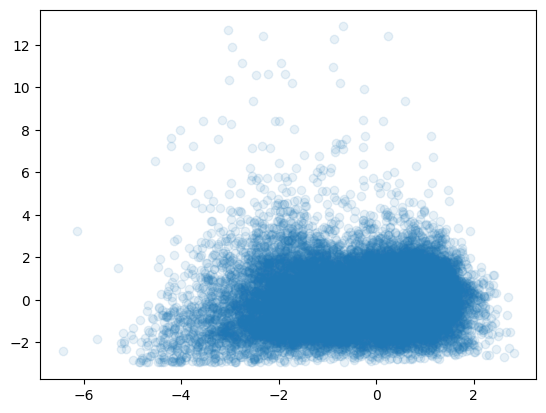

In [12]:
feature_means = cell_covariates.mean(axis=0)
feature_stds = cell_covariates.std(axis=0)
feature_medians = np.median(cell_covariates, axis=0)
feature_mads = np.median(np.abs(cell_covariates - feature_medians), axis=0)

cell_covariates_z_scored = (cell_covariates - feature_means) / feature_stds

plt.scatter(x=cell_covariates_z_scored[:, 0], y=cell_covariates_z_scored[:, 1], alpha=0.1)

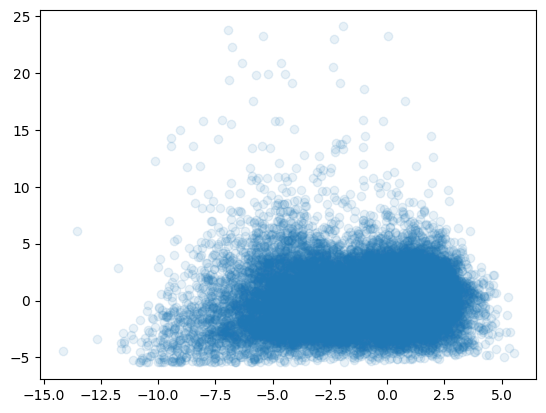

In [13]:
cell_covariates_robust_z_scored = (cell_covariates - feature_medians) / feature_mads
plt.scatter(x=cell_covariates_robust_z_scored[:, 0], y=cell_covariates_robust_z_scored[:, 1], alpha=0.1)

In [14]:
gene_obs = jnp.array(rna_subset.X.toarray()).astype(int)
guide_obs = jnp.array(grna_subset.X).astype(bool)
# guide_obs = guide_obs.at[:, 2:].set(0)
guide_obs.shape

(45053, 762)

In [15]:
targeted_in_subset = grna_subset.varm["element_targeted"].sum() > 0
selected_elements = targeted_in_subset[targeted_in_subset].index
guide_targets = grna_subset.varm["element_targeted"][selected_elements]
guide_targets

,ACTB_TSS,ACTG1_TSS,ACYP1_TSS,ADIPOR1_TSS,ALDH1A2_TSS,APEX1_TSS,APLP2_TSS,ARF6_TSS,ARID1A_TSS,ARL4A_TSS,...,WDR61_TSS,WSB1_TSS,XPO1_TSS,YWHAE_TSS,YWHAQ_TSS,ZC3H8_TSS,ZNF273_TSS,ZNF593_TSS,ZNHIT1_TSS,ZRANB2_TSS
ACTB_TSS|1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTB_TSS|2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACYP1_TSS|1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF593_TSS|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
ZNHIT1_TSS|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
ZNHIT1_TSS|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
ZRANB2_TSS|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [34]:
# gene_idx = 1

# n_plot_genes = min(4, len(genes))
# print(n_plot_genes)
# fig, axs = plt.subplots(3, n_plot_genes, sharex="col")


# # Control histogram
# for gene_idx in range(n_plot_genes):
#     max_count = gene_obs[:, gene_idx].max()
#     n_bins = min(int(max_count) + 1, 50)
#     hist_bins = np.linspace(0, max_count + 1, n_bins)
#     hist_bins = None
#     control_gene_obs = gene_obs[guide_obs.sum(axis=1) == 0, gene_idx].squeeze()
#     axs[0][gene_idx].hist(control_gene_obs, bins=hist_bins, density=True)
#     axs[0][gene_idx].axvline(control_gene_obs.mean(), color="black")
#     axs[0][gene_idx].set_ylabel("Density (control)")
#     axs[0][gene_idx].set_title(genes[gene_idx])

#     # Guide histograms
#     for i in range(2):
#         guide_gene_obs = gene_obs[guide_obs[:, i].astype(bool), gene_idx].squeeze()
#         axs[i + 1][gene_idx].axvline(guide_gene_obs.mean(), color="black")
#         # print(np.log2(guide_gene_obs.mean() / control_gene_obs.mean()))
#         axs[i + 1][gene_idx].hist(guide_gene_obs, bins=hist_bins, density=True)
#         axs[i + 1][gene_idx].set_ylabel(f"Density (guide {i})")
#         # axs[i + 1][gene_idx].set_title(f"")

#     axs[i + 1][gene_idx].set_xlabel("Gene counts per cell")
# plt.tight_layout()
# plt.show()

In [17]:
perturbseq_guide = perturbseq_guide_autonormal_turbo()
model_args = (gene_obs,)
model_kwargs = {
    "guide_obs": guide_obs,
    "guide_targets": jnp.array(guide_targets.values),  # all target same element
    "covariates": cell_covariates_robust_z_scored,
    "likelihood": "NegBin",
    "subsample_size": 1024,
}

svi_result = run_svi(
    model_args,
    model_kwargs,
    perturbseq_model_turbo,
    perturbseq_guide,
    lr=0.1,
    n_steps=500,
)

100%|██████████| 1000/1000 [00:35<00:00, 28.38it/s, init loss: 164191792.0000, avg. loss [951-1000]: 34682772.7200]


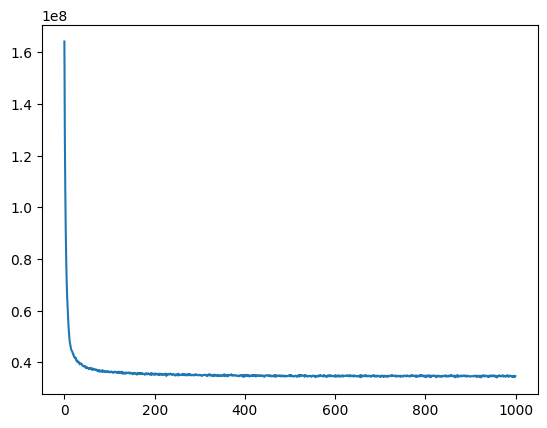

In [18]:
plt.plot(svi_result.losses)

In [19]:
params = svi_result.params
params

{'covariate_weights_auto_loc': Array([[ 0.19779576,  0.21466671,  0.23196405, ...,  0.32571188,
          0.254031  ,  0.19604458],
        [-0.06201772, -0.1326883 , -0.02955904, ..., -0.01757775,
         -0.02691771, -0.00729829],
        [-0.01713186,  0.04700691, -0.05649694, ..., -0.00270851,
          0.02188881,  0.01989065]], dtype=float32),
 'covariate_weights_auto_scale': Array([[0.00422126, 0.00319341, 0.00395309, ..., 0.00395439, 0.00259932,
         0.00496829],
        [0.00376923, 0.00429775, 0.00284717, ..., 0.00226184, 0.00372026,
         0.00819497],
        [0.00504801, 0.00664086, 0.00313681, ..., 0.00240543, 0.00289617,
         0.00478303]], dtype=float32),
 'dispersion_auto_loc': Array([ 1.9873872 ,  1.0060347 ,  1.8616353 ,  2.2040646 ,  0.70041203,
         2.2172556 ,  1.719461  ,  1.9693389 ,  1.9232619 ,  1.8411622 ,
         2.338507  ,  1.4685024 ,  0.90729743,  2.328673  ,  2.3608603 ,
         2.6893117 ,  2.086616  , -0.25690317,  1.1323215 ,  2.03886

In [20]:
perturbseq_guide.median(params)

{'mean': Array([1.98411617e+01, 7.88675356e+00, 1.27908063e+00, 2.75624704e+00,
        2.58272314e+00, 2.29522586e+00, 1.69405186e+00, 2.16583729e+00,
        7.70758629e-01, 4.79094267e+00, 5.41357219e-01, 1.07635927e+00,
        8.62241447e-01, 1.11365318e+01, 9.25418735e-01, 4.10559702e+00,
        1.30351770e+00, 9.39441025e-01, 9.08991432e+00, 3.84429646e+00,
        2.18613720e+00, 1.05937910e+00, 2.80375385e+01, 1.60869920e+00,
        2.35965252e+00, 1.88524222e+00, 1.67151761e+00, 8.35861504e-01,
        3.54540348e+00, 2.73605132e+00, 2.48940110e+00, 1.25183737e+00,
        1.05960655e+00, 2.13846636e+00, 9.34620500e-01, 6.58443511e-01,
        6.28686905e+00, 6.87357306e-01, 1.41943431e+00, 1.06210887e+00,
        1.12684369e+00, 4.39052057e+00, 8.37896109e-01, 1.66498795e+01,
        4.73374939e+00, 5.91766357e-01, 3.60627747e+00, 1.69694102e+00,
        6.47693872e-01, 6.69697189e+00, 1.43141150e+00, 6.12511826e+00,
        1.86944532e+00, 4.83100700e+00, 2.75694871e+00, 

In [21]:
for k, v in perturbseq_guide.median(params).items():
    print(k, v.shape)

mean (373,)
dispersion (373,)
efficiency (762, 373)
log2_fold_change (381, 373)
covariate_weights (3, 373)


In [22]:
z_vals = params["log2_fold_change_auto_loc"] / params["log2_fold_change_auto_scale"]
z_vals

Array([[-3.4567574e+01,  3.0653692e+01,  5.5052028e+00, ...,
         1.1396804e+00,  2.1003506e+00, -3.6633921e-01],
       [ 2.1467226e+00, -1.6586542e+01, -1.0098747e+00, ...,
         4.5341067e+00, -2.2126930e+00, -4.0097287e-01],
       [-4.1007003e-01, -2.0410597e+00, -1.2456470e+01, ...,
         3.6305423e+00,  2.1279020e+00, -2.8307313e-01],
       ...,
       [-7.3427820e-01,  3.8593745e+00,  1.4809124e+00, ...,
        -5.4488140e+01,  4.9379544e+00,  2.1160667e-01],
       [ 1.4263079e+00,  1.3968768e+00, -1.1900305e+00, ...,
        -1.6912512e+00, -3.1751244e+01,  5.2443650e-02],
       [-5.0667661e-01, -7.4367267e-01,  5.9402090e-01, ...,
         6.3664055e-01,  2.2726433e+00, -6.0241551e+00]], dtype=float32)

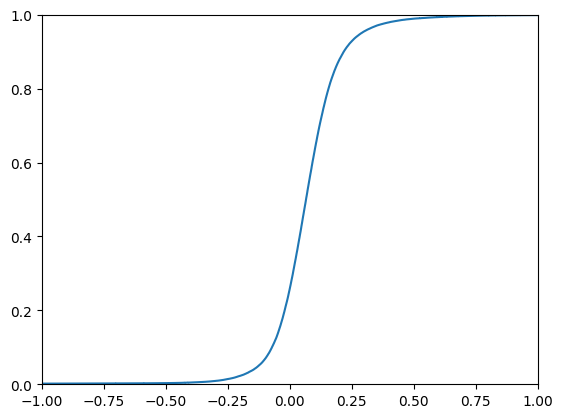

In [23]:
plt.ecdf(perturbseq_guide.quantiles(params, 0.95)["log2_fold_change"].reshape(-1))
plt.xlim(-1, 1)
plt.show()

In [24]:
alpha = 0.001
threshold = 0.5
negative_pairs = perturbseq_guide.quantiles(params, 1 - alpha)["log2_fold_change"][0, ...] < -threshold
positive_pairs = perturbseq_guide.quantiles(params, alpha)["log2_fold_change"][0, ...] > threshold
significant_pairs = negative_pairs | positive_pairs
significant_pairs.sum()
# significant_pairs.shape

Array(475, dtype=int32)

In [25]:
element_idxs, gene_idxs = jnp.where(significant_pairs)
significant_pairs_df = pd.DataFrame(
    {"gene": [genes[i] for i in gene_idxs], "element": [selected_elements.values[i] for i in element_idxs]}
)
significant_pairs_df
# for a, b in zip(*):
# print(selected_elements.values[a], genes[b])
# selected_elements

,gene,element
0,ACTB,ACTB_TSS
1,ACTG1,ACTB_TSS
2,ACTG1,ACTG1_TSS
3,ACYP1,ACYP1_TSS
4,ADIPOR1,ADIPOR1_TSS
...,...,...
470,PCNA,ZC3H8_TSS
471,ZC3H8,ZC3H8_TSS
472,ZNF593,ZNF593_TSS
473,ZNHIT1,ZNHIT1_TSS


In [28]:
if test_ntcs:
    significant_pairs_df[significant_pairs_df["element"].str.contains("random|scrambled", regex=True)].value_counts(
        "gene"
    )

In [29]:
significant_pairs_df.value_counts("gene")

gene
HBD         33
EEF1A1      16
ID3         11
DLK1        11
SAT1         9
            ..
JAGN1        1
ITGB1BP1     1
IRF2BP2      1
IMPDH2       1
ZRANB2       1
Name: count, Length: 329, dtype: int64

In [31]:
significant_pairs_df.value_counts("element")

element
DDX3X_TSS     7
CYB5B_TSS     5
EIF4E_TSS     5
MED10_TSS     5
TMED10_TSS    4
             ..
MRPL33_TSS    1
MRPL40_TSS    1
MRPL4_TSS     1
MRPL52_TSS    1
ZRANB2_TSS    1
Name: count, Length: 329, dtype: int64

In [32]:
significant_pairs_df.query("gene=='HBD'")

,gene,element
15,HBD,ATP6V1F_TSS
42,HBD,CCND2_TSS
50,HBD,CERS2_TSS
80,HBD,CYB5B_TSS
88,HBD,DDX3X_TSS
134,HBD,FAM96A_TSS
141,HBD,FH_TSS
146,HBD,GADD45A_TSS
151,HBD,GLUL_TSS
156,HBD,GNPDA1_TSS
